# Section 21: Transfer learning

In [1]:
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader, Subset

import torchvision
import torchvision.transforms as T

import copy

## Transfer learning: MNIST -> FMNIST

In [2]:
device = torch.device('mps' if torch.mps.is_available() else 'cpu')

In [3]:
data = np.loadtxt(open('mnist_train_small.csv', 'rb'), delimiter=',')

labels = data[:, 0]
data = data[:, 1:]
data_norm = data / np.max(data)
data_norm = data_norm.reshape(data_norm.shape[0], 1, 28, 28)

data_t = torch.tensor(data_norm).float().to(device)
labels_t = torch.tensor(labels).long().to(device)

train_data, test_data, train_labels, test_labels = train_test_split(data_t, labels_t, test_size=.1)

train_dataset = TensorDataset(train_data, train_labels)
test_dataset = TensorDataset(test_data, test_labels)

mnist_train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, drop_last=True)
mnist_test_loader = DataLoader(test_dataset, batch_size=test_dataset.tensors[0].shape[0])

In [4]:
transform = T.Compose([T.ToTensor(), T.Normalize(.5, .5)])

In [5]:
fmnist = torchvision.datasets.FashionMNIST(root='./fmnist', download=True, transform=transform)

images = np.expand_dims(fmnist.data, axis=1)
labels = fmnist.targets
images = images / np.max(images)

data_t = torch.tensor(images).float().to(device)
labels_t = labels.to(device)

train_data, test_data, train_labels, test_labels = train_test_split(data_t, labels_t, test_size=.2)

train_dataset = TensorDataset(train_data, train_labels)
test_dataset = TensorDataset(test_data, test_labels)

fmnist_train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, drop_last=True)
fmnist_test_loader = DataLoader(test_dataset, batch_size=test_dataset.tensors[0].shape[0])

In [6]:
def create_model(print_toggle_param=False):
    class Net(nn.Module):
        def __init__(self):
            super().__init__()

            self.conv1 = nn.Conv2d(1, 10, 5, 1, 1)
            self.conv2 = nn.Conv2d(10, 20, 5, 1, 1)

            expected_size = np.floor((5 + 2 * 0 - 1) / 1) + 1
            expected_size = 20 * int(expected_size ** 2)

            self.fc1 = nn.Linear(expected_size, 50)
            self.output = nn.Linear(50, 10)

        def forward(self, x_param):
            if print_toggle_param: print(f"Input: {x_param.shape}")

            x_local = F.relu(F.max_pool2d(self.conv1(x_param), 2))

            if print_toggle_param: print(f"Layer conv1/pool1: {x_local.shape}")

            x_local = F.relu(F.max_pool2d(self.conv2(x_local), 2))

            if print_toggle_param: print(f"Layer conv2/pool2: {x_local.shape}")

            x_local = torch.flatten(x_local, start_dim=1)

            if print_toggle_param: print(f"Vectorized: {x_local.shape}")

            x_local = F.relu(self.fc1(x_local))

            if print_toggle_param: print(f"Layer fc1: {x_local.shape}")

            x_local = self.output(x_local)

            if print_toggle_param: print(f"Layer out: {x_local.shape}")

            return x_local

    net_local = Net().to(device)
    loss_function_local = nn.CrossEntropyLoss()
    optimizer_local = torch.optim.SGD(net_local.parameters(), lr=.005)

    return net_local, loss_function_local, optimizer_local

In [7]:
def train_model(net_local, loss_function_local, optimizer_local, train_loader_local, test_loader_local, epochs_nr_param=5):
    losses_local = []
    train_accuracies_local = []
    test_accuracies_local = []
     
    for epoch in range(epochs_nr_param):
        batch_losses = []
        batch_accuracies = []
         
        net_local.train()
         
        for X_local, y_local in train_loader_local:
            y_pred_local = net_local(X_local)
            loss_local = loss_function_local(y_pred_local, y_local)
               
            optimizer_local.zero_grad()
            loss_local.backward()
            optimizer_local.step()
            
            batch_losses.append(loss_local.item())
               
            correct_predictions = (torch.argmax(y_pred_local, axis=1) == y_local).float()
             
            batch_accuracies.append(100 * torch.mean(correct_predictions).item())

        train_accuracies_local.append(np.mean(batch_accuracies))
        losses_local.append(np.mean(batch_losses))
        net_local.eval()
          
        X_local, y_local = next(iter(test_loader_local))
          
        with torch.no_grad():
            y_pred_local = net_local(X_local)
          
        correct_predictions = (torch.argmax(y_pred_local, axis=1) == y_local).float()
          
        test_accuracies_local.append(100 * torch.mean(correct_predictions).item())
     
    return train_accuracies_local, test_accuracies_local, losses_local, net_local

In [8]:
mnist_net, loss_function, optimizer = create_model()
train_accuracies, test_accuracies, losses, _ = train_model(mnist_net, loss_function, optimizer, mnist_train_loader, mnist_test_loader)

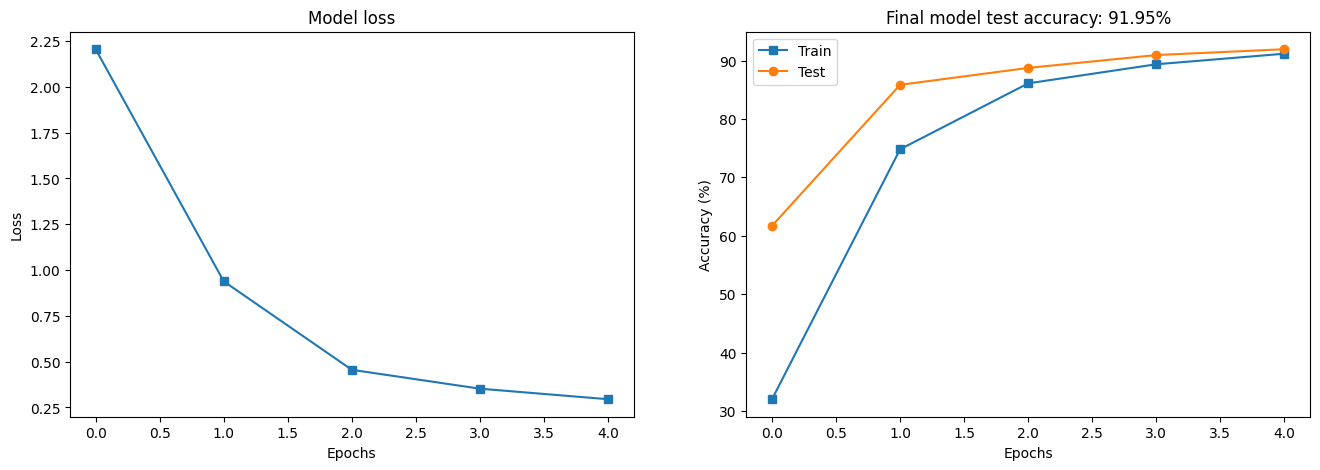

In [9]:
_, ax = plt.subplots(1, 2, figsize=(16, 5))

ax[0].plot(losses, 's-')
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('Loss')
ax[0].set_title("Model loss")

ax[1].plot(train_accuracies, 's-', label='Train')
ax[1].plot(test_accuracies, 'o-', label='Test')
ax[1].set_xlabel('Epochs')
ax[1].set_ylabel("Accuracy (%)")
ax[1].set_title(f"Final model test accuracy: {test_accuracies[-1]:.2f}%")
ax[1].legend()

plt.show()

In [10]:
X, y = next(iter(fmnist_test_loader))
y_pred = mnist_net(X)

fmnist_accuracy = 100 * torch.mean((torch.argmax(y_pred, axis=1) == y).float())

print(f"MnistNet test accuracy on the FMNIST data: {fmnist_accuracy:.2f}%")

MnistNet test accuracy on the FMNIST data: 5.78%


In [11]:
fmnist_net, loss_function, optimizer = create_model()

fmnist_net.load_state_dict(mnist_net.state_dict())

<All keys matched successfully>

In [12]:
train_accuracies, test_accuracies, _, _ = train_model(fmnist_net, loss_function, optimizer, fmnist_train_loader, fmnist_test_loader, 1)

print(f"FmnistNet train accuracy on the FMNIST data (after transfer learning): {train_accuracies[-1]:.2f}%")
print(f"FmnistNet test accuracy on the FMNIST data (after transfer learning): {test_accuracies[-1]:.2f}%")

FmnistNet train accuracy on the FMNIST data (after transfer learning): 69.32%
FmnistNet test accuracy on the FMNIST data (after transfer learning): 75.55%


## CodeChallenge: letters to numbers

In [13]:
emnist_letters = torchvision.datasets.EMNIST(root='emnist', split='letters', download=True)

images = emnist_letters.data.view([emnist_letters.data.shape[0], 1, 28, 28]).float()
labels = copy.deepcopy(emnist_letters.targets) - 1
images = images / torch.max(images)

train_data, test_data, train_labels, test_labels = train_test_split(images.to(device), labels.to(device), test_size=.1)

train_dataset = TensorDataset(train_data, train_labels)
test_dataset = TensorDataset(test_data, test_labels)

emnist_letters_train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, drop_last=True)
emnist_letters_test_loader = DataLoader(test_dataset, batch_size=test_dataset.tensors[0].shape[0])

In [14]:
emnist_digits = torchvision.datasets.EMNIST(root='emnist', split='digits', download=True)

images = emnist_digits.data.view([emnist_digits.data.shape[0], 1, 28, 28]).float()
labels = copy.deepcopy(emnist_digits.targets)
images = images / torch.max(images)

train_data, test_data, train_labels, test_labels = train_test_split(images.to(device), labels.to(device), test_size=.1)

train_dataset = TensorDataset(train_data, train_labels)
test_dataset = TensorDataset(test_data, test_labels)

emnist_digits_train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, drop_last=True)
emnist_digits_test_loader = DataLoader(test_dataset, batch_size=test_dataset.tensors[0].shape[0])

In [15]:
def create_model():
    class Net(nn.Module):
        def __init__(self):
            super().__init__()
            
            self.conv1  = nn.Conv2d(1, 6, 3, padding=1)
            self.bnorm1 = nn.BatchNorm2d(6)
            
            self.conv2  = nn.Conv2d(6, 6, 3, padding=1)
            self.bnorm2 = nn.BatchNorm2d(6)
            
            self.fc1 = nn.Linear(7 * 7 * 6, 50)
            self.output = nn.Linear(50, 26)
            
        def forward(self, x_param):
            x_local = F.max_pool2d(self.conv1(x_param), 2)
            x_local = F.leaky_relu(self.bnorm1(x_local))
            
            x_local = F.max_pool2d(self.conv2(x_local), 2)
            x_local = F.leaky_relu(self.bnorm2(x_local))
            
            x_local = torch.flatten(x_local, start_dim=1)

            x_local = F.leaky_relu(self.fc1(x_local))
            x_local = self.output(x_local)

            return x_local
        
    net_local = Net().to(device)
    loss_function_local = nn.CrossEntropyLoss()
    optimizer_local = torch.optim.Adam(net_local.parameters(), lr=.001)
    
    return net_local, loss_function_local, optimizer_local

In [16]:
emnist_letters_net, loss_function, optimizer = create_model()
train_accuracies, test_accuracies, losses, _ = train_model(emnist_letters_net, loss_function, optimizer, emnist_letters_train_loader, emnist_letters_test_loader)

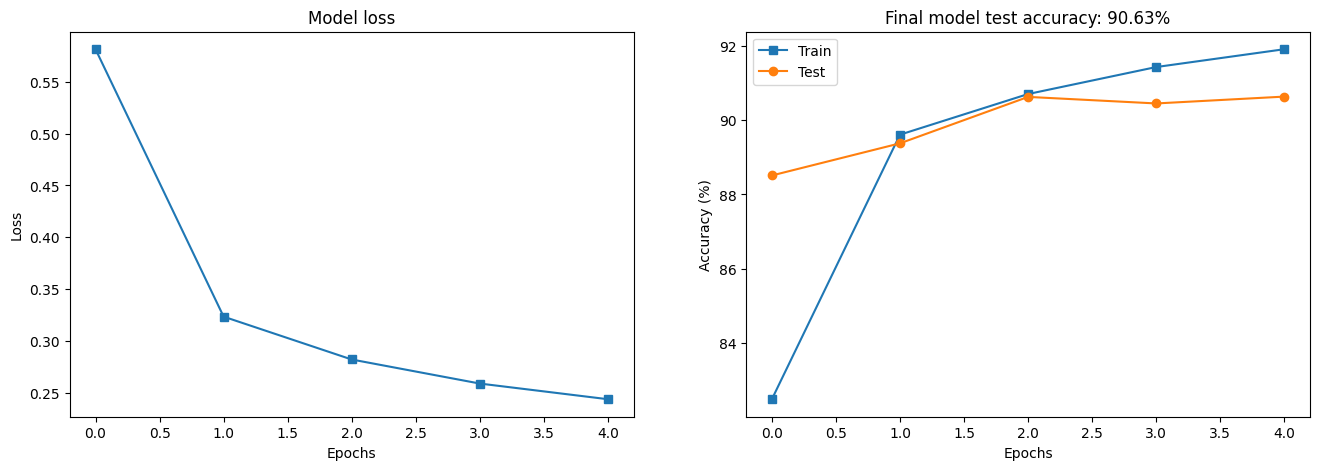

In [17]:
_, ax = plt.subplots(1, 2, figsize=(16, 5))

ax[0].plot(losses, 's-')
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('Loss')
ax[0].set_title("Model loss")

ax[1].plot(train_accuracies, 's-', label='Train')
ax[1].plot(test_accuracies, 'o-', label='Test')
ax[1].set_xlabel('Epochs')
ax[1].set_ylabel("Accuracy (%)")
ax[1].set_title(f"Final model test accuracy: {test_accuracies[-1]:.2f}%")
ax[1].legend()

plt.show()

In [18]:
emnist_digits_net_1, loss_function, _ = create_model()

emnist_digits_net_1.load_state_dict(emnist_letters_net.state_dict())

emnist_digits_net_1.output = nn.Linear(50, 10).to(device)
optimizer = torch.optim.Adam(emnist_digits_net_1.parameters(), lr=.001)

In [19]:
train_accuracies, test_accuracies, _, _ = train_model(emnist_digits_net_1, loss_function, optimizer, emnist_digits_train_loader, emnist_digits_test_loader, 1)

print(f"EmnistDigitsNet train accuracy on the EMNIST digits data (after transfer learning): {train_accuracies[-1]:.2f}%")
print(f"EmnistDigitsNet test accuracy on the EMNIST digits data (after transfer learning): {test_accuracies[-1]:.2f}%")

EmnistDigitsNet train accuracy on the EMNIST digits data (after transfer learning): 97.96%
EmnistDigitsNet test accuracy on the EMNIST digits data (after transfer learning): 98.82%


In [20]:
emnist_digits_net_2, loss_function, _ = create_model()

emnist_digits_net_2.load_state_dict(emnist_letters_net.state_dict())

emnist_digits_net_2.output = nn.Linear(50, 10).to(device)
optimizer = torch.optim.Adam(emnist_digits_net_2.parameters(), lr=.001)
layer_names_to_fine_tune = ['fc1.weight', 'fc1.bias', 'output.weight', 'output.bias',]

for name, parameters in emnist_digits_net_2.named_parameters():
    if name not in layer_names_to_fine_tune:
        parameters.requires_grad = False

In [21]:
train_accuracies, test_accuracies, _, _ = train_model(emnist_digits_net_2, loss_function, optimizer, emnist_digits_train_loader, emnist_digits_test_loader, 1)

print(f"EmnistDigitsNet train accuracy on the EMNIST digits data (after transfer learning): {train_accuracies[-1]:.2f}%")
print(f"EmnistDigitsNet test accuracy on the EMNIST digits data (after transfer learning): {test_accuracies[-1]:.2f}%")

EmnistDigitsNet train accuracy on the EMNIST digits data (after transfer learning): 98.07%
EmnistDigitsNet test accuracy on the EMNIST digits data (after transfer learning): 98.98%


## Transfer learning with ResNet-18

In [22]:
transform = T.Compose([
    T.ToTensor(),
    T.Normalize(mean=[.485, .456, .406], std=[.229, .224, .225])]
)
stl10_train = torchvision.datasets.STL10(root='./stl10', download=True, split='train', transform=transform)
stl10_test = torchvision.datasets.STL10(root='./stl10', download=True, split='test', transform=transform)

stl10_train_loader = DataLoader(stl10_train, batch_size=32, shuffle=True, drop_last=True)
stl10_test_loader = DataLoader(stl10_test, batch_size=256)

In [23]:
print(f"Data shapes (train/test): {stl10_train.data.shape}/{stl10_test.data.shape}")
print(f"Data value range: {(np.min(stl10_train.data), np.max(stl10_train.data))}")
print(f"Data categories: {stl10_train.classes}")

Data shapes (train/test): (5000, 3, 96, 96)/(8000, 3, 96, 96)
Data value range: (np.uint8(0), np.uint8(255))
Data categories: ['airplane', 'bird', 'car', 'cat', 'deer', 'dog', 'horse', 'monkey', 'ship', 'truck']


In [24]:
X, y = next(iter(stl10_train_loader))

print(f"Data shapes (train/test): {X.data.shape}")
print(f"Data value range: {(torch.min(X.data), torch.max(X.data))}")

Data shapes (train/test): torch.Size([32, 3, 96, 96])
Data value range: (tensor(-2.1179), tensor(2.6400))


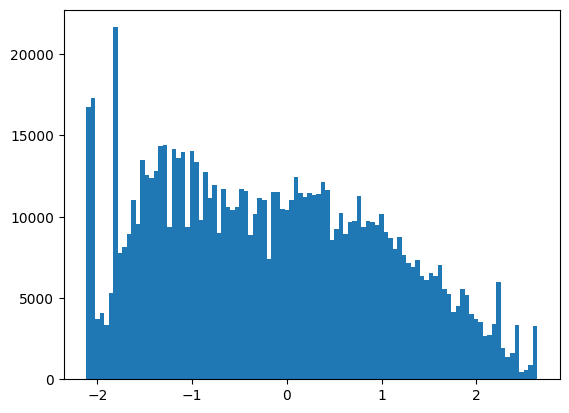

In [25]:
plt.hist(X.data.numpy().flatten(), 100)
plt.show()

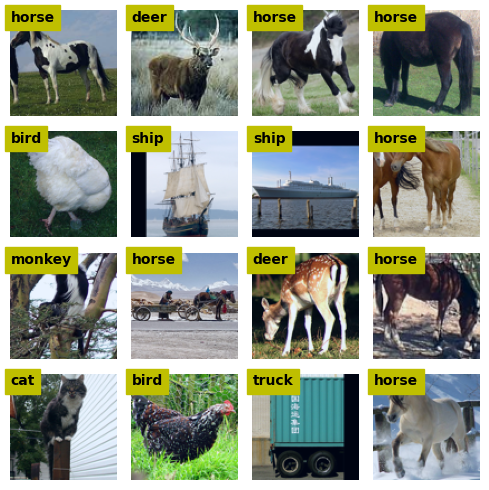

In [26]:
_, axs = plt.subplots(4, 4, figsize=(5, 5))

for (i, ax) in enumerate(axs.flatten()):
    image = X.data[i].numpy().transpose((1, 2, 0))
    image = image - np.min(image)
    image = image / np.max(image)
    
    label = stl10_train.classes[y[i]]
    
    ax.imshow(image)
    ax.text(0, 0, label, ha='left', va='top', fontweight='bold', color='k', backgroundcolor='y')
    ax.axis('off')
    
plt.tight_layout()
plt.show()

In [27]:
res_net_weights = torchvision.models.ResNet18_Weights.DEFAULT
res_net = torchvision.models.resnet18(weights=res_net_weights)

In [28]:
for parameters in res_net.parameters():
    parameters.requires_grad = False
    
res_net.fc = nn.Linear(512, 10)

res_net.to(device)

loss_function = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(res_net.parameters(), lr=.001, momentum=.9)

In [29]:
def train_model(net_local, loss_function_local, optimizer_local, train_loader_local, test_loader_local, epochs_nr_param=5):
    train_losses_local = []
    test_losses_local = []
    train_accuracies_local = []
    test_accuracies_local = []
     
    for epoch in range(epochs_nr_param):
        batch_losses = []
        batch_accuracies = []
         
        net_local.train()
         
        for X_local, y_local in train_loader_local:
            X_local = X_local.to(device)
            y_local = y_local.to(device)
            y_pred_local = net_local(X_local)
            loss_local = loss_function_local(y_pred_local, y_local)
               
            optimizer_local.zero_grad()
            loss_local.backward()
            optimizer_local.step()
            
            batch_losses.append(loss_local.item())
               
            correct_predictions = (torch.argmax(y_pred_local, axis=1) == y_local).float()
             
            batch_accuracies.append(100 * torch.mean(correct_predictions).item())

        train_accuracies_local.append(np.mean(batch_accuracies))
        train_losses_local.append(np.mean(batch_losses))
        net_local.eval()
          
        X_local, y_local = next(iter(test_loader_local))
        X_local = X_local.to(device)
        y_local = y_local.to(device)
          
        with torch.no_grad():
            y_pred_local = net_local(X_local)
            loss_local = loss_function_local(y_pred_local, y_local)
          
        test_losses_local.append(loss_local.item())

        correct_predictions = (torch.argmax(y_pred_local, axis=1) == y_local).float()

        test_accuracies_local.append(100 * torch.mean(correct_predictions).item())
        
        print(f"Finished epoch {epoch + 1}/{epochs_nr_param}. Test accuracy = {test_accuracies_local[epoch]:.2f}%")
     
    return train_accuracies_local, test_accuracies_local, train_losses_local, test_losses_local, net_local

In [30]:
train_accuracies, test_accuracies, train_losses, test_losses, stl10_net = train_model(res_net, loss_function, optimizer, stl10_train_loader, stl10_test_loader)

Finished epoch 1/5. Test accuracy = 71.48%
Finished epoch 2/5. Test accuracy = 71.48%
Finished epoch 3/5. Test accuracy = 74.22%
Finished epoch 4/5. Test accuracy = 76.56%
Finished epoch 5/5. Test accuracy = 76.17%


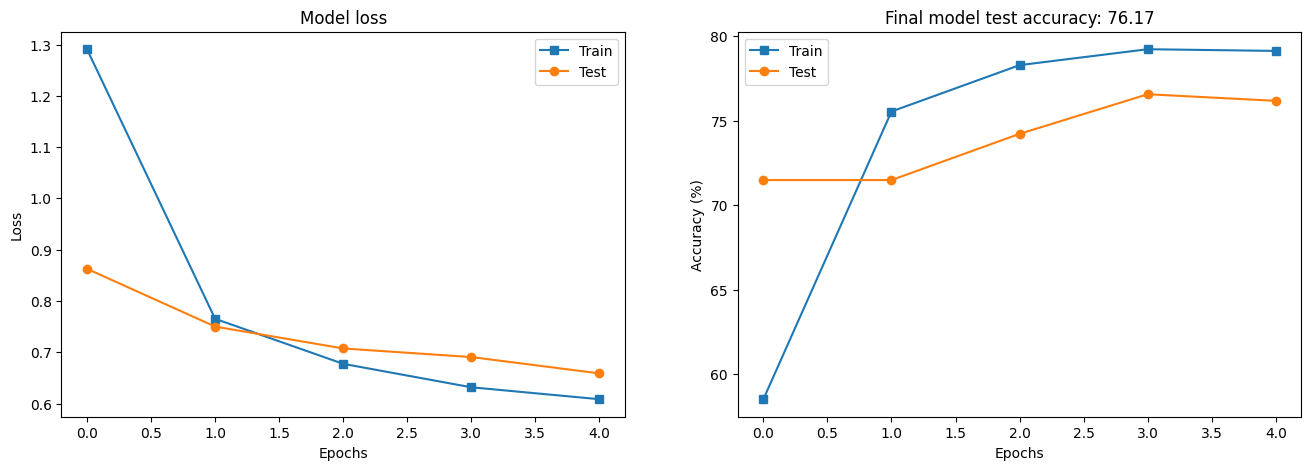

In [31]:
_, ax = plt.subplots(1, 2, figsize=(16, 5))

ax[0].plot(train_losses, 's-', label='Train')
ax[0].plot(test_losses, 'o-', label='Test')
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('Loss')
ax[0].set_title("Model loss")
ax[0].legend()

ax[1].plot(train_accuracies, 's-', label='Train')
ax[1].plot(test_accuracies, 'o-', label='Test')
ax[1].set_xlabel('Epochs')
ax[1].set_ylabel("Accuracy (%)")
ax[1].set_title(f"Final model test accuracy: {test_accuracies[-1]:.2f}")
ax[1].legend()

plt.show()

In [32]:
X, y = next(iter(stl10_test_loader))
X = X.to(device)
y = y.to(device)

stl10_net.eval()

y_pred = torch.argmax(stl10_net(X), axis=1)

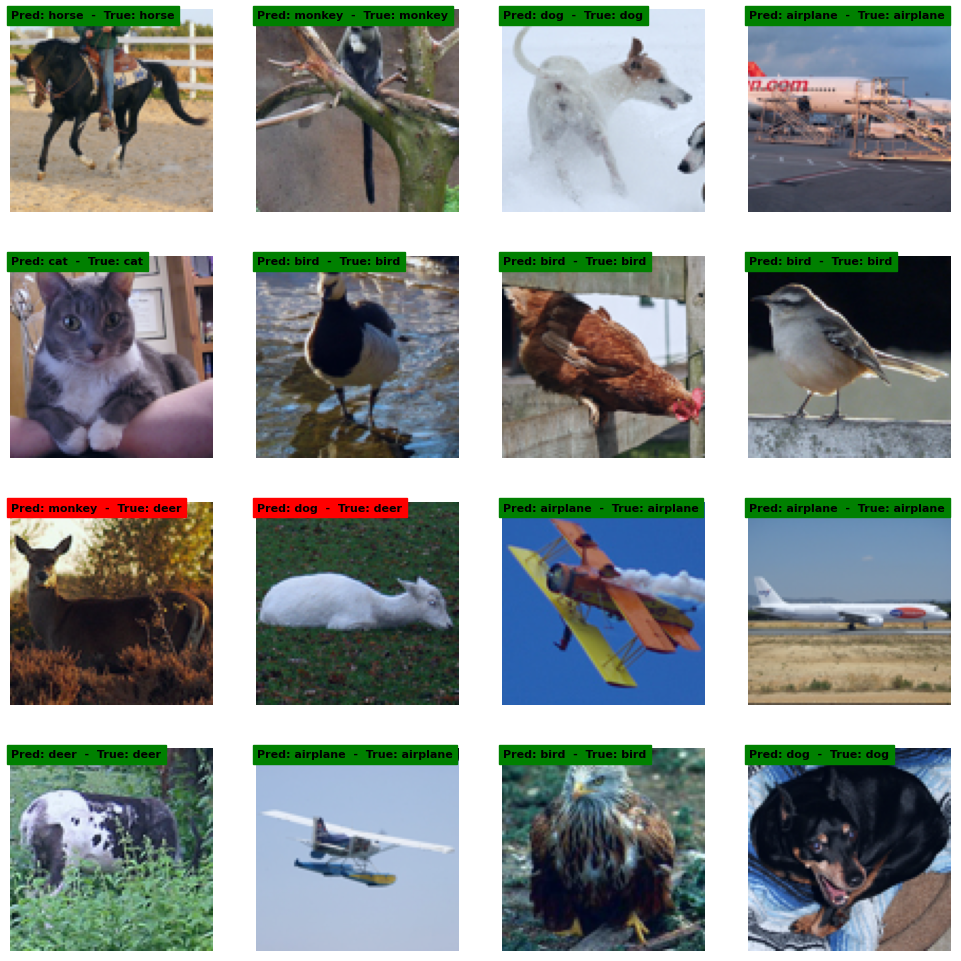

In [33]:
_, axs = plt.subplots(4, 4, figsize=(10, 10))

for (i, ax) in enumerate(axs.flatten()):
    image = X.data[i].cpu().numpy().transpose((1, 2, 0))
    image = image - np.min(image)
    image = image / np.max(image)

    pred_label = stl10_test.classes[y_pred[i]]
    true_label = stl10_test.classes[y[i]]
    title = f"Pred: {pred_label}  -  True: {true_label}"
    title_color = 'g' if true_label == pred_label else 'r'
    
    ax.imshow(image)
    ax.text(0, 0, title, ha='left', va='top', fontweight='bold', color='k', backgroundcolor=title_color, fontsize=8)
    ax.axis('off')
    
plt.tight_layout()
plt.show()

## CodeChallenge: VGG-16

In [34]:
transform = T.Compose([
    T.Resize(224),
    T.ToTensor(),
    T.Normalize(mean=[.485, .456, .406], std=[.229, .224, .225])]
)
stl10_train = torchvision.datasets.STL10(root='./stl10', download=True, split='train', transform=transform)
stl10_test = torchvision.datasets.STL10(root='./stl10', download=True, split='test', transform=transform)

stl10_train_loader = DataLoader(stl10_train, batch_size=32, shuffle=True, drop_last=True)
stl10_test_loader = DataLoader(stl10_test, batch_size=256)

In [35]:
vgg_net_weights = torchvision.models.VGG16_Weights.DEFAULT
vgg_net = torchvision.models.vgg16(weights=vgg_net_weights)

In [36]:
for parameters in vgg_net.parameters():
    parameters.requires_grad = False
    
vgg_net.classifier[6] = nn.Linear(vgg_net.classifier[6].in_features, 10)

vgg_net.to(device)

loss_function = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(vgg_net.parameters(), lr=.001, momentum=.9)

In [37]:
train_accuracies, test_accuracies, train_losses, test_losses, stl10_net = train_model(vgg_net, loss_function, optimizer, stl10_train_loader, stl10_test_loader)

Finished epoch 1/5. Test accuracy = 93.36%
Finished epoch 2/5. Test accuracy = 93.75%
Finished epoch 3/5. Test accuracy = 94.53%
Finished epoch 4/5. Test accuracy = 93.75%
Finished epoch 5/5. Test accuracy = 94.92%


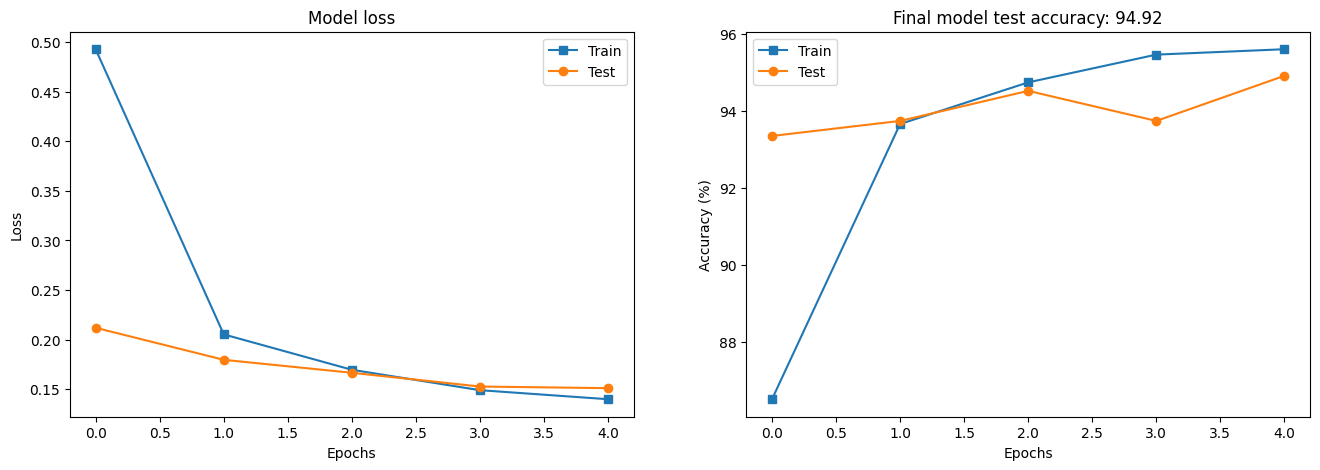

In [38]:
_, ax = plt.subplots(1, 2, figsize=(16, 5))

ax[0].plot(train_losses, 's-', label='Train')
ax[0].plot(test_losses, 'o-', label='Test')
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('Loss')
ax[0].set_title("Model loss")
ax[0].legend()

ax[1].plot(train_accuracies, 's-', label='Train')
ax[1].plot(test_accuracies, 'o-', label='Test')
ax[1].set_xlabel('Epochs')
ax[1].set_ylabel("Accuracy (%)")
ax[1].set_title(f"Final model test accuracy: {test_accuracies[-1]:.2f}")
ax[1].legend()

plt.show()

## Pretraining with autoencoders

In [39]:
epochs_nr = 10

In [40]:
transform = T.Compose([
    T.ToTensor(),
    T.Normalize(.5, .5)]
)
fmnist_train = torchvision.datasets.FashionMNIST(root='./fmnist', train=True, download=True, transform=transform)
fmnist_val_test = torchvision.datasets.FashionMNIST(root='./fmnist', train=False, download=True, transform=transform)

random_indexes = np.random.permutation(10000)
fmnist_val = Subset(fmnist_val_test, random_indexes[:6000])
fmnist_test = Subset(fmnist_val_test, random_indexes[6000:])

fmnist_train_loader = DataLoader(fmnist_train, batch_size=32, shuffle=True, drop_last=True)
fmnist_val_loader = DataLoader(fmnist_val, batch_size=len(fmnist_val))
fmnist_test_loader = DataLoader(fmnist_test, batch_size=len(fmnist_test))

In [41]:
def create_model():
    class AeNet(nn.Module):
        def __init__(self):
            super().__init__()

            self.enc_conv1 = nn.Conv2d(1, 16, 3, 2, 1)
            self.enc_conv2 = nn.Conv2d(16, 32, 3, 2, 1)
            self.dec_conv1 = nn.ConvTranspose2d(32, 16, 4, 2, 1)
            self.dec_conv2 = nn.ConvTranspose2d(16, 1, 4, 2, 1)

        def forward(self, x_param):
            x_local = F.leaky_relu(self.enc_conv1(x_param))
            x_local = F.leaky_relu(self.enc_conv2(x_local))
            x_local = F.leaky_relu(self.dec_conv1(x_local))
            x_local = self.dec_conv2(x_local)

            return x_local

    ae_net_local = AeNet().to(device)
    loss_function_local = nn.MSELoss()
    optimizer_local = torch.optim.Adam(ae_net_local.parameters(), lr=.001)

    return ae_net_local, loss_function_local, optimizer_local

In [42]:
ae_net, loss_function, _ = create_model()

X, _ = next(iter(fmnist_train_loader))
X = X.to(device)
y_pred = ae_net(X)

print(f"Output shape: {y_pred.shape}")

loss = loss_function(y_pred, X)

print()
print(f"Loss: {loss}")

Output shape: torch.Size([32, 1, 28, 28])

Loss: 0.5883384943008423


In [43]:
def train_model(ae_net_local, loss_function_local, optimizer_local, train_loader_local, test_loader_local, epochs_nr_param=epochs_nr):
    train_losses_local = []
    test_losses_local = []

    for epoch in range(epochs_nr_param):
        batch_losses = []

        ae_net_local.train()

        for X_local, _ in train_loader_local:
            X_local = X_local.to(device)
            y_pred_local = ae_net_local(X_local)
            loss_local = loss_function_local(y_pred_local, X_local)

            optimizer_local.zero_grad()
            loss_local.backward()
            optimizer_local.step()

            batch_losses.append(loss_local.item())

        train_losses_local.append(np.mean(batch_losses))

        batch_losses = []

        ae_net_local.eval()

        for X_local, _ in test_loader_local:
            X_local = X_local.to(device)

            with torch.no_grad():
                y_pred_local = ae_net_local(X_local)
                loss_local = loss_function_local(y_pred_local, X_local)

            batch_losses.append(loss_local.item())

        test_losses_local.append(np.mean(batch_losses))

        print(f"Finished epoch {epoch + 1}/{epochs_nr_param}")

    return train_losses_local, test_losses_local, ae_net_local

In [44]:
ae_net, loss_function, optimizer = create_model()
train_losses, val_losses, ae_net = train_model(ae_net, loss_function, optimizer, fmnist_train_loader, fmnist_val_loader)

Finished epoch 1/10
Finished epoch 2/10
Finished epoch 3/10
Finished epoch 4/10
Finished epoch 5/10
Finished epoch 6/10
Finished epoch 7/10
Finished epoch 8/10
Finished epoch 9/10
Finished epoch 10/10


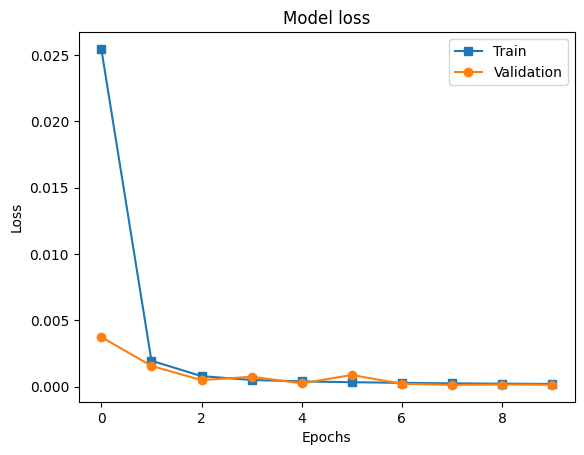

In [45]:
plt.plot(train_losses, 's-', label='Train')
plt.plot(val_losses, 'o-', label='Validation')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title("Model loss")
plt.legend()

plt.show()

In [46]:
X, y = next(iter(fmnist_val_loader))

ae_net.cpu()
ae_net.eval()

y_pred = ae_net(X)

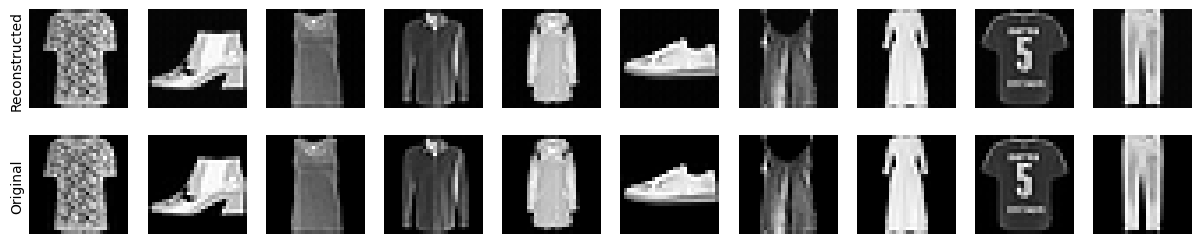

In [47]:
_, ax = plt.subplots(2, 10, figsize=(15, 3))

for i in range(10):
  image = y_pred[i, 0, :, :].detach()
  image = image / 2 + .5

  ax[0, i].imshow(image, cmap='gray')
  ax[0, i].axis('off')

  image = X[i, 0, :, :].detach()
  image = image / 2 + .5

  ax[1, i].imshow(image, cmap='gray')
  ax[1, i].axis('off')

  if i==0:
    ax[0, 0].text(-6, 14, 'Reconstructed', rotation=90, va='center')
    ax[1, 0].text(-6, 14, 'Original', rotation=90, va='center')

plt.show()

In [48]:
def create_model():
    class FmnistNet(nn.Module):
        def __init__(self):
            super().__init__()

            self.enc_conv1 = nn.Conv2d(1, 16, 3, 2, 1)
            self.enc_conv2 = nn.Conv2d(16, 32, 3, 2, 1)
            self.fc1 = nn.Linear(7 * 7 * 32, 50)
            self.output = nn.Linear(50, 10)

        def forward(self, x_param):
            x_local = F.leaky_relu(self.enc_conv1(x_param))
            x_local = F.leaky_relu(self.enc_conv2(x_local))
            x_local = torch.flatten(x_local, start_dim=1)
            x_local = F.leaky_relu(self.fc1(x_local))
            x_local = self.output(x_local)

            return x_local

    fmnist_net_local = FmnistNet().to(device)
    loss_function_local = nn.CrossEntropyLoss()
    optimizer_local = torch.optim.Adam(fmnist_net_local.parameters(), lr=.001)

    return fmnist_net_local, loss_function_local, optimizer_local

In [49]:
fmnist_net, loss_function, _ = create_model()

X, y = next(iter(fmnist_train_loader))
X = X.to(device)
y = y.to(device)
y_pred = fmnist_net(X)

print(f"Output shape: {y_pred.shape}")

loss = loss_function(y_pred, y)

print()
print(f"Loss: {loss}")

Output shape: torch.Size([32, 10])

Loss: 2.291154146194458


In [50]:
def train_model(net_local, loss_function_local, optimizer_local, train_loader_local, test_loader_local, epochs_nr_param=epochs_nr):
    train_losses_local = []
    test_losses_local = []
    train_accuracies_local = []
    test_accuracies_local = []

    for epoch in range(epochs_nr_param):
        batch_losses = []
        batch_accuracies = []

        net_local.train()

        for X_local, y_local in train_loader_local:
            X_local = X_local.to(device)
            y_local = y_local.to(device)
            y_pred_local = net_local(X_local)
            loss_local = loss_function_local(y_pred_local, y_local)

            optimizer_local.zero_grad()
            loss_local.backward()
            optimizer_local.step()

            batch_losses.append(loss_local.item())

            correct_predictions = (torch.argmax(y_pred_local, axis=1) == y_local).float()

            batch_accuracies.append(100 * torch.mean(correct_predictions).item())

        train_accuracies_local.append(np.mean(batch_accuracies))
        train_losses_local.append(np.mean(batch_losses))

        batch_losses = []
        batch_accuracies = []

        net_local.eval()

        for X_local, y_local in test_loader_local:
            X_local = X_local.to(device)
            y_local = y_local.to(device)

            with torch.no_grad():
                y_pred_local = net_local(X_local)
                loss_local = loss_function_local(y_pred_local, y_local)

            batch_losses.append(loss_local.item())

            correct_predictions = (torch.argmax(y_pred_local, axis=1) == y_local).float()

            batch_accuracies.append(100 * torch.mean(correct_predictions).item())

        test_accuracies_local.append(np.mean(batch_accuracies))
        test_losses_local.append(np.mean(batch_losses))

        print(f"Finished epoch {epoch + 1}/{epochs_nr_param}. Test accuracy = {test_accuracies_local[epoch]:.2f}%")

    return train_accuracies_local, test_accuracies_local, train_losses_local, test_losses_local, net_local

In [51]:
fmnist_net, loss_function, optimizer = create_model()
train_accuracies, val_accuracies, train_losses, val_losses, fmnist_net = train_model(fmnist_net, loss_function, optimizer, fmnist_train_loader, fmnist_val_loader)

Finished epoch 1/10. Test accuracy = 86.15%
Finished epoch 2/10. Test accuracy = 87.92%
Finished epoch 3/10. Test accuracy = 88.53%
Finished epoch 4/10. Test accuracy = 89.30%
Finished epoch 5/10. Test accuracy = 89.52%
Finished epoch 6/10. Test accuracy = 90.02%
Finished epoch 7/10. Test accuracy = 90.33%
Finished epoch 8/10. Test accuracy = 89.98%
Finished epoch 9/10. Test accuracy = 90.27%
Finished epoch 10/10. Test accuracy = 90.48%


In [52]:
fmnist_net.eval()

X,y = next(iter(fmnist_test_loader))
X = X.to(device)
y = y.to(device)

with torch.no_grad():
  y_pred = fmnist_net(X)
  test_loss = loss_function(y_pred, y)

test_loss = test_loss.item()
test_accuracy  = 100 * torch.mean((torch.argmax(y_pred, axis=1) == y).float()).item()

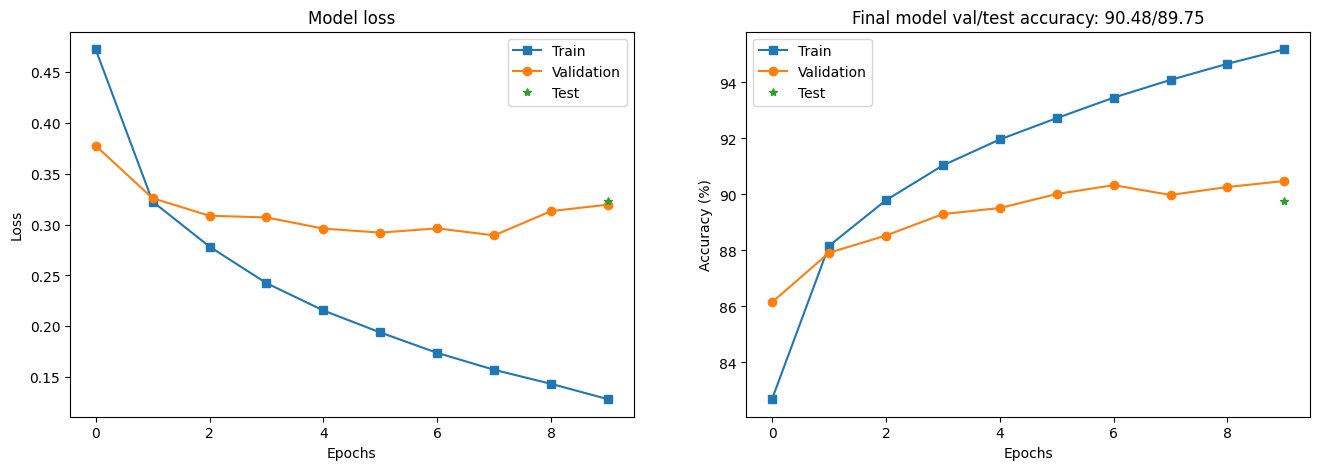

In [53]:
_, ax = plt.subplots(1, 2, figsize=(16, 5))

ax[0].plot(train_losses, 's-', label='Train')
ax[0].plot(val_losses, 'o-', label='Validation')
ax[0].plot(epochs_nr - 1, test_loss, '*', label='Test')
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('Loss')
ax[0].set_title("Model loss")
ax[0].legend()

ax[1].plot(train_accuracies, 's-', label='Train')
ax[1].plot(val_accuracies, 'o-', label='Validation')
ax[1].plot(epochs_nr - 1, test_accuracy, '*', label='Test')
ax[1].set_xlabel('Epochs')
ax[1].set_ylabel("Accuracy (%)")
ax[1].set_title("Final model val/test accuracy: %.2f/%.2f" %(val_accuracies[-1], test_accuracy))
ax[1].legend()

plt.show()

In [54]:
pre_fmnist_net, pre_loss_function, pre_optimizer = create_model()

ae_net.to(device)

for target, source in zip(pre_fmnist_net.named_parameters(), ae_net.named_parameters()):
    if 'enc' in target[0]:
        target[1].data = copy.deepcopy(source[1].data)

In [55]:
pre_train_accuracies, pre_val_accuracies, pre_train_losses, pre_val_losses, pre_fmnist_net = train_model(pre_fmnist_net, pre_loss_function, pre_optimizer, fmnist_train_loader, fmnist_val_loader)

Finished epoch 1/10. Test accuracy = 86.77%
Finished epoch 2/10. Test accuracy = 86.62%
Finished epoch 3/10. Test accuracy = 88.57%
Finished epoch 4/10. Test accuracy = 89.70%
Finished epoch 5/10. Test accuracy = 89.32%
Finished epoch 6/10. Test accuracy = 89.18%
Finished epoch 7/10. Test accuracy = 89.18%
Finished epoch 8/10. Test accuracy = 90.20%
Finished epoch 9/10. Test accuracy = 89.22%
Finished epoch 10/10. Test accuracy = 90.28%


In [56]:
pre_fmnist_net.eval()

X,y = next(iter(fmnist_test_loader))
X = X.to(device)
y = y.to(device)

with torch.no_grad():
  y_pred = pre_fmnist_net(X)
  pre_test_loss = loss_function(y_pred, y)

pre_test_loss = pre_test_loss.item()
pre_test_accuracy  = 100 * torch.mean((torch.argmax(y_pred, axis=1) == y).float()).item()

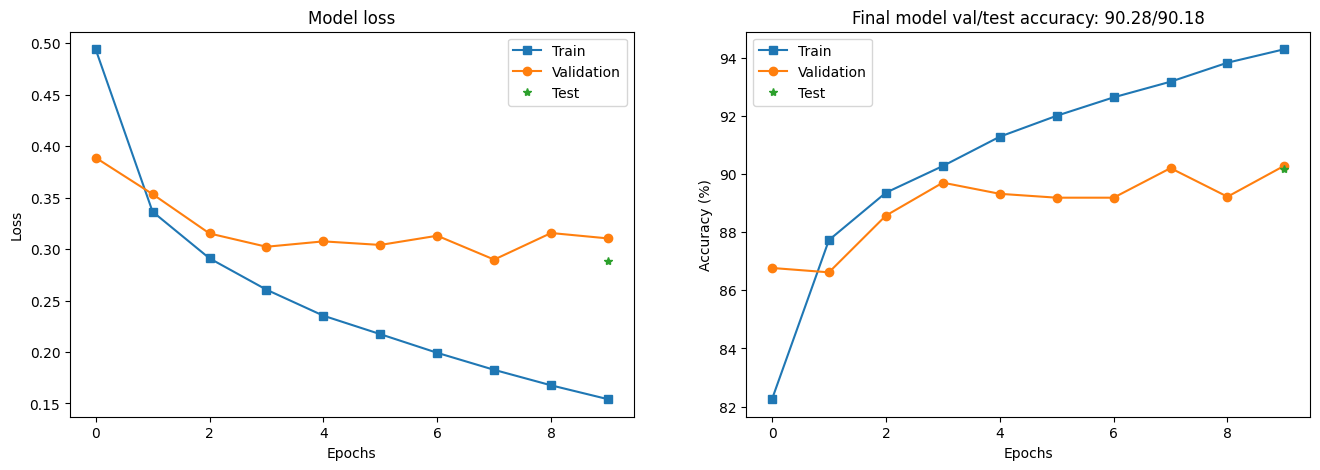

In [57]:
_, ax = plt.subplots(1, 2, figsize=(16, 5))

ax[0].plot(pre_train_losses, 's-', label='Train')
ax[0].plot(pre_val_losses, 'o-', label='Validation')
ax[0].plot(epochs_nr - 1, pre_test_loss, '*', label='Test')
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('Loss')
ax[0].set_title("Model loss")
ax[0].legend()

ax[1].plot(pre_train_accuracies, 's-', label='Train')
ax[1].plot(pre_val_accuracies, 'o-', label='Validation')
ax[1].plot(epochs_nr - 1, pre_test_accuracy, '*', label='Test')
ax[1].set_xlabel('Epochs')
ax[1].set_ylabel("Accuracy (%)")
ax[1].set_title("Final model val/test accuracy: %.2f/%.2f" %(pre_val_accuracies[-1], pre_test_accuracy))
ax[1].legend()

plt.show()

In [58]:
x = X[10, :, :, :].view(1, 1, 28, 28)

fmnist_activation = F.leaky_relu(F.conv2d(x, fmnist_net.enc_conv1.weight, fmnist_net.enc_conv1.bias, stride=2, padding=1))
pre_fmnist_activation = F.leaky_relu(F.conv2d(x, pre_fmnist_net.enc_conv1.weight, pre_fmnist_net.enc_conv1.bias, stride=2, padding=1))

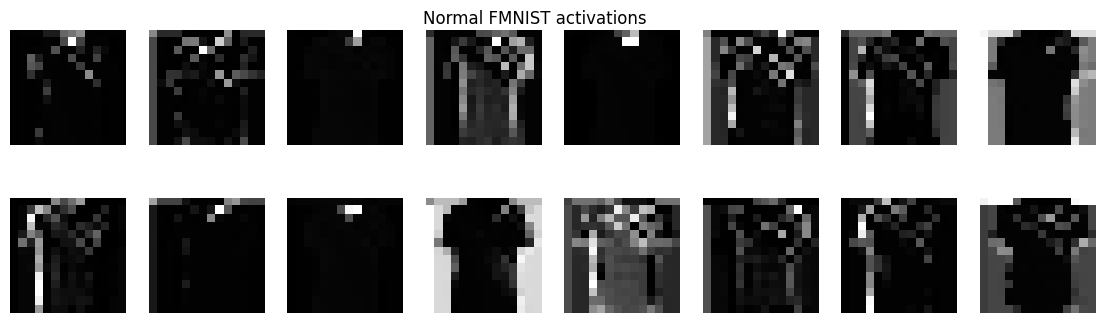

In [59]:
_, axs = plt.subplots(2, 8, figsize=(14, 4))

for i, ax in enumerate(axs.flatten()):
  image = torch.squeeze(fmnist_activation[0, i, :, :]).detach().cpu()

  ax.imshow(image, cmap='gray')
  ax.axis('off')

plt.suptitle("Normal FMNIST activations", y=.9)
plt.show()

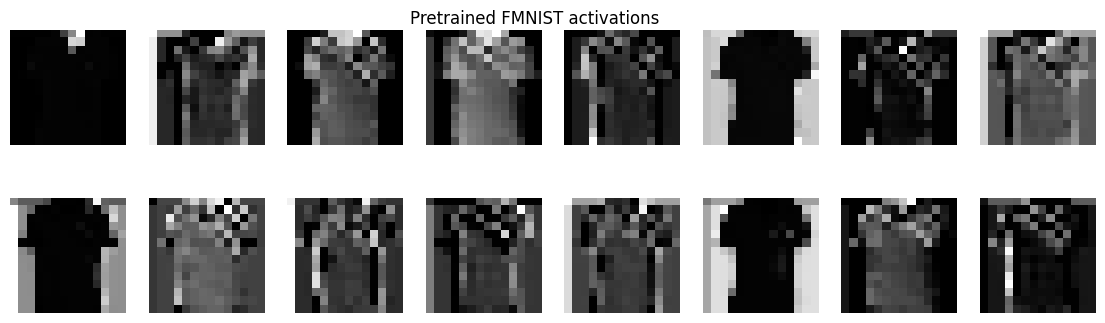

In [60]:
_, axs = plt.subplots(2, 8, figsize=(14, 4))

for i, ax in enumerate(axs.flatten()):
  image = torch.squeeze(pre_fmnist_activation[0, i, :, :]).detach().cpu()

  ax.imshow(image, cmap='gray')
  ax.axis('off')

plt.suptitle("Pretrained FMNIST activations", y=.9)
plt.show()

## CIFAR10 with autoencoder-pretrained model

In [61]:
transform = T.Compose([
    T.ToTensor(),
    T.Normalize([.5, .5, .5], [.5, .5, .5])
])

cifar10_full_train = torchvision.datasets.CIFAR10(root='cifar10', train=True, download=True, transform=transform)
cifar10_full_test = torchvision.datasets.CIFAR10(root='cifar10', train=False, download=True, transform=transform)

cifar10_train_full_loader = DataLoader(cifar10_full_train, batch_size=32, shuffle=True, drop_last=True)
cifar10_test_full_loader = DataLoader(cifar10_full_test, batch_size=256)

In [62]:
cifar10_small_train = Subset(cifar10_full_train, range(2000))
cifar10_small_test = Subset(cifar10_full_test, range(2000))

cifar10_train_small_loader = DataLoader(cifar10_small_train, batch_size=32, shuffle=True)
cifar10_test_small_loader = DataLoader(cifar10_small_test, batch_size=256)

In [63]:
def create_model():
    class AeNet(nn.Module):
        def __init__(self):
            super().__init__()

            self.enc_conv1 = nn.Conv2d(3, 16, 4, 2, 1)
            self.enc_conv2 = nn.Conv2d(16, 32, 4, 2, 1)
            self.enc_conv3 = nn.Conv2d(32, 64, 4, 2, 1)
            self.dec_conv1 = nn.ConvTranspose2d(64, 32, 4, 2, 1)
            self.dec_conv2 = nn.ConvTranspose2d(32, 16, 4, 2, 1)
            self.dec_conv3 = nn.ConvTranspose2d(16, 3, 4, 2, 1)

        def forward(self, x_param):
            x_local = F.leaky_relu(self.enc_conv1(x_param))
            x_local = F.leaky_relu(self.enc_conv2(x_local))
            x_local = F.leaky_relu(self.enc_conv3(x_local))
            x_local = F.leaky_relu(self.dec_conv1(x_local))
            x_local = F.leaky_relu(self.dec_conv2(x_local))
            x_local = self.dec_conv3(x_local)

            return x_local

    ae_net_local = AeNet().to(device)
    loss_function_local = nn.MSELoss()
    optimizer_local = torch.optim.Adam(ae_net_local.parameters(), lr=.001)

    return ae_net_local, loss_function_local, optimizer_local

In [64]:
ae_net, loss_function, _ = create_model()

X, _ = next(iter(cifar10_train_small_loader))
X = X.to(device)
y_pred = ae_net(X)

print(f"Output shape: {y_pred.shape}")

loss = loss_function(y_pred, X)

print()
print(f"Loss: {loss}")

Output shape: torch.Size([32, 3, 32, 32])

Loss: 0.2385542243719101


In [65]:
def train_model(ae_net_local, loss_function_local, optimizer_local, train_loader_local, test_loader_local, epochs_nr_param=epochs_nr):
    train_losses_local = []
    test_losses_local = []

    for epoch in range(epochs_nr_param):
        batch_losses = []

        ae_net_local.train()

        for X_local, _ in train_loader_local:
            X_local = X_local.to(device)
            y_pred_local = ae_net_local(X_local)
            loss_local = loss_function_local(y_pred_local, X_local)

            optimizer_local.zero_grad()
            loss_local.backward()
            optimizer_local.step()

            batch_losses.append(loss_local.item())

        train_losses_local.append(np.mean(batch_losses))

        batch_losses = []

        ae_net_local.eval()

        for X_local, _ in test_loader_local:
            X_local = X_local.to(device)

            with torch.no_grad():
                y_pred_local = ae_net_local(X_local)
                loss_local = loss_function_local(y_pred_local, X_local)

            batch_losses.append(loss_local.item())

        test_losses_local.append(np.mean(batch_losses))

        print(f"Finished epoch {epoch + 1}/{epochs_nr_param}")

    return train_losses_local, test_losses_local, ae_net_local

In [66]:
ae_net, loss_function, optimizer = create_model()
train_losses, test_losses, ae_net = train_model(ae_net, loss_function, optimizer, cifar10_train_full_loader, cifar10_test_full_loader, 15)

Finished epoch 1/15
Finished epoch 2/15
Finished epoch 3/15
Finished epoch 4/15
Finished epoch 5/15
Finished epoch 6/15
Finished epoch 7/15
Finished epoch 8/15
Finished epoch 9/15
Finished epoch 10/15
Finished epoch 11/15
Finished epoch 12/15
Finished epoch 13/15
Finished epoch 14/15
Finished epoch 15/15


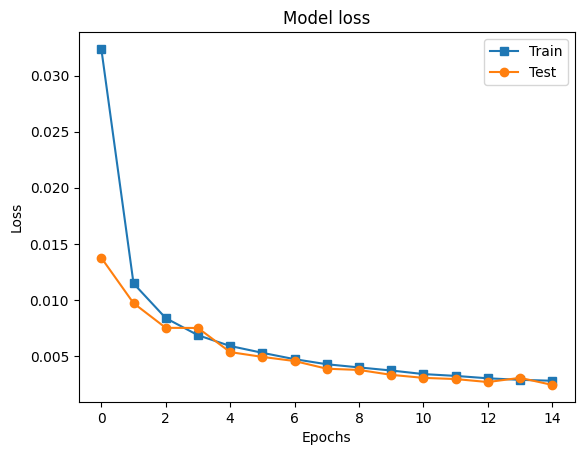

In [67]:
plt.plot(train_losses, 's-', label='Train')
plt.plot(test_losses, 'o-', label='Test')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title("Model loss")
plt.legend()

plt.show()

In [68]:
X, y = next(iter(cifar10_test_small_loader))

ae_net.cpu()
ae_net.eval()

y_pred = ae_net(X)

In [69]:
y_pred.shape

torch.Size([256, 3, 32, 32])

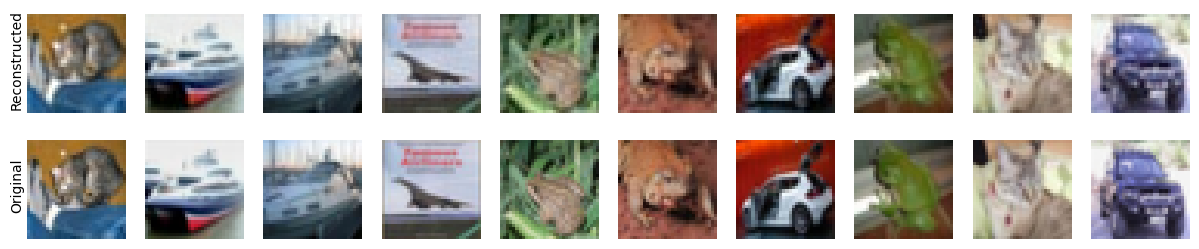

In [70]:
_, ax = plt.subplots(2, 10, figsize=(15, 3))

for i in range(10):
    image = y_pred[i, :, :, :].detach().numpy().transpose((1,2,0))
    image = (image / 2 + .5).clip(0, 1)

    ax[0, i].imshow(image)
    ax[0, i].axis('off')

    image = X[i, :, :, :].detach().numpy().transpose((1,2,0))
    image = image / 2 + .5

    ax[1, i].imshow(image)
    ax[1, i].axis('off')

    if i == 0:
        ax[0, 0].text(-6, 14, 'Reconstructed', rotation=90, va='center')
        ax[1, 0].text(-6, 14, 'Original', rotation=90, va='center')

plt.show()

In [71]:
def create_model():
    class Cifar10Net(nn.Module):
        def __init__(self):
            super().__init__()

            self.enc_conv1 = nn.Conv2d(3, 16, 4, 2, 1)
            self.enc_conv2 = nn.Conv2d(16, 32, 4, 2, 1)
            self.enc_conv3 = nn.Conv2d(32, 64, 4, 2, 1)
            self.fc1 = nn.Linear(4 * 4 * 64, 128)
            self.fc2 = nn.Linear(128, 64)
            self.output = nn.Linear(64, 10)

        def forward(self, x_param):
            x_local = F.leaky_relu(self.enc_conv1(x_param))
            x_local = F.leaky_relu(self.enc_conv2(x_local))
            x_local = F.leaky_relu(self.enc_conv3(x_local))
            x_local = torch.flatten(x_local, start_dim=1)
            x_local = F.leaky_relu(self.fc1(x_local))
            x_local = F.leaky_relu(self.fc2(x_local))
            x_local = self.output(x_local)

            return x_local

    cifar10_net_local = Cifar10Net().to(device)
    loss_function_local = nn.CrossEntropyLoss()
    optimizer_local = torch.optim.Adam(cifar10_net_local.parameters(), lr=.001)

    return cifar10_net_local, loss_function_local, optimizer_local

In [72]:
cifar10_net, loss_function, _ = create_model()

X, y = next(iter(cifar10_train_small_loader))
X = X.to(device)
y = y.to(device)
y_pred = cifar10_net(X)

print(f"Output shape: {y_pred.shape}")

loss = loss_function(y_pred, y)

print()
print(f"Loss: {loss}")

Output shape: torch.Size([32, 10])

Loss: 2.296182632446289


In [73]:
def train_model(net_local, loss_function_local, optimizer_local, train_loader_local, test_loader_local, epochs_nr_param=epochs_nr):
    train_losses_local = []
    test_losses_local = []
    train_accuracies_local = []
    test_accuracies_local = []

    for epoch in range(epochs_nr_param):
        batch_losses = []
        batch_accuracies = []

        net_local.train()

        for X_local, y_local in train_loader_local:
            X_local = X_local.to(device)
            y_local = y_local.to(device)
            y_pred_local = net_local(X_local)
            loss_local = loss_function_local(y_pred_local, y_local)

            optimizer_local.zero_grad()
            loss_local.backward()
            optimizer_local.step()

            batch_losses.append(loss_local.item())

            correct_predictions = (torch.argmax(y_pred_local, axis=1) == y_local).float()

            batch_accuracies.append(100 * torch.mean(correct_predictions).item())

        train_accuracies_local.append(np.mean(batch_accuracies))
        train_losses_local.append(np.mean(batch_losses))

        batch_losses = []
        batch_accuracies = []

        net_local.eval()

        for X_local, y_local in test_loader_local:
            X_local = X_local.to(device)
            y_local = y_local.to(device)

            with torch.no_grad():
                y_pred_local = net_local(X_local)
                loss_local = loss_function_local(y_pred_local, y_local)

            batch_losses.append(loss_local.item())

            correct_predictions = (torch.argmax(y_pred_local, axis=1) == y_local).float()

            batch_accuracies.append(100 * torch.mean(correct_predictions).item())

        test_accuracies_local.append(np.mean(batch_accuracies))
        test_losses_local.append(np.mean(batch_losses))

        print(f"Finished epoch {epoch + 1}/{epochs_nr_param}. Test accuracy = {test_accuracies_local[epoch]:.2f}%")

    return train_accuracies_local, test_accuracies_local, train_losses_local, test_losses_local, net_local

In [74]:
cifar10_net, loss_function, optimizer = create_model()
train_accuracies, test_accuracies, train_losses, test_losses, cifar10_net = train_model(cifar10_net, loss_function, optimizer, cifar10_train_small_loader, cifar10_test_small_loader)

Finished epoch 1/10. Test accuracy = 28.82%
Finished epoch 2/10. Test accuracy = 29.96%
Finished epoch 3/10. Test accuracy = 36.42%
Finished epoch 4/10. Test accuracy = 37.15%
Finished epoch 5/10. Test accuracy = 41.20%
Finished epoch 6/10. Test accuracy = 42.63%
Finished epoch 7/10. Test accuracy = 43.36%
Finished epoch 8/10. Test accuracy = 42.88%
Finished epoch 9/10. Test accuracy = 42.58%
Finished epoch 10/10. Test accuracy = 42.49%


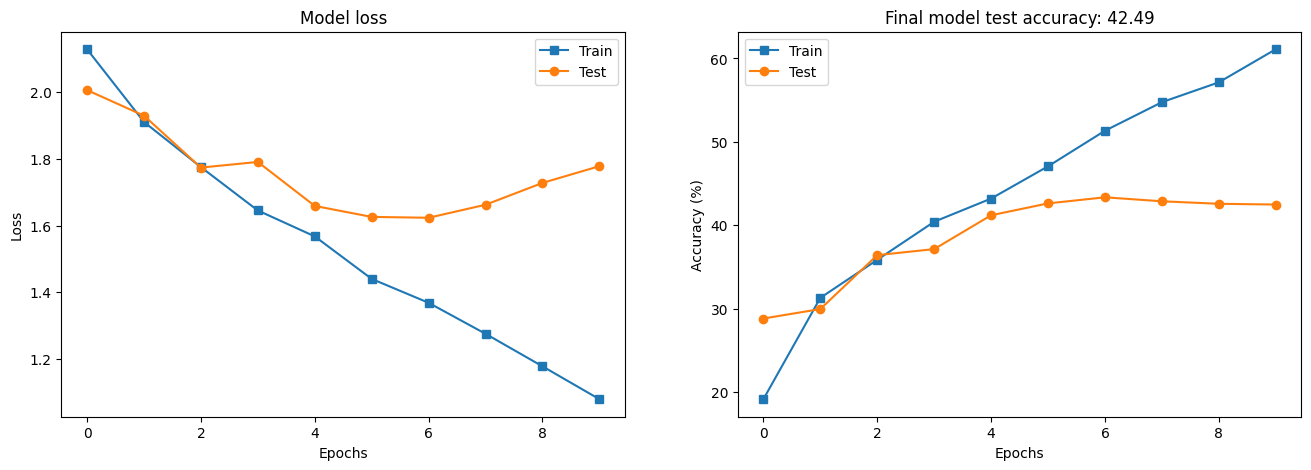

In [75]:
_, ax = plt.subplots(1, 2, figsize=(16, 5))

ax[0].plot(train_losses, 's-', label='Train')
ax[0].plot(test_losses, 'o-', label='Test')
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('Loss')
ax[0].set_title("Model loss")
ax[0].legend()

ax[1].plot(train_accuracies, 's-', label='Train')
ax[1].plot(test_accuracies, 'o-', label='Test')
ax[1].set_xlabel('Epochs')
ax[1].set_ylabel("Accuracy (%)")
ax[1].set_title("Final model test accuracy: %.2f" %test_accuracies[-1])
ax[1].legend()

plt.show()

In [76]:
pre_cifar10_net, pre_loss_function, pre_optimizer = create_model()

ae_net.to(device)

for target, source in zip(pre_cifar10_net.named_parameters(), ae_net.named_parameters()):
    if 'enc' in target[0]:
        target[1].data = copy.deepcopy(source[1].data)

In [77]:
pre_train_accuracies, pre_test_accuracies, pre_train_losses, pre_test_losses, pre_cifar10_net = train_model(pre_cifar10_net, pre_loss_function, pre_optimizer, cifar10_train_small_loader, cifar10_test_small_loader)

Finished epoch 1/10. Test accuracy = 25.47%
Finished epoch 2/10. Test accuracy = 35.16%
Finished epoch 3/10. Test accuracy = 37.86%
Finished epoch 4/10. Test accuracy = 39.37%
Finished epoch 5/10. Test accuracy = 38.39%
Finished epoch 6/10. Test accuracy = 42.37%
Finished epoch 7/10. Test accuracy = 42.78%
Finished epoch 8/10. Test accuracy = 43.56%
Finished epoch 9/10. Test accuracy = 41.55%
Finished epoch 10/10. Test accuracy = 41.14%


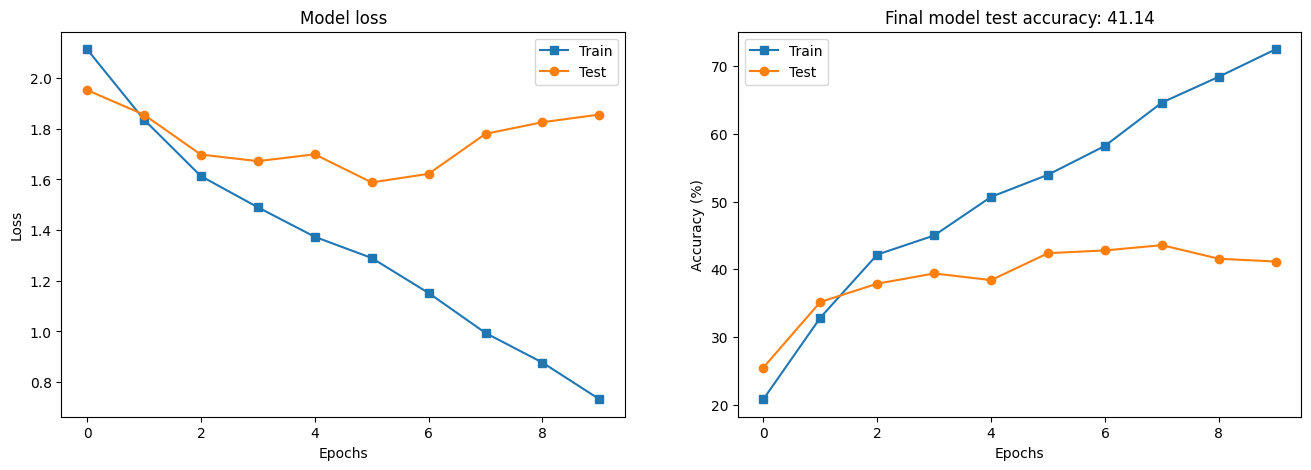

In [78]:
_, ax = plt.subplots(1, 2, figsize=(16, 5))

ax[0].plot(pre_train_losses, 's-', label='Train')
ax[0].plot(pre_test_losses, 'o-', label='Test')
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('Loss')
ax[0].set_title("Model loss")
ax[0].legend()

ax[1].plot(pre_train_accuracies, 's-', label='Train')
ax[1].plot(pre_test_accuracies, 'o-', label='Test')
ax[1].set_xlabel('Epochs')
ax[1].set_ylabel("Accuracy (%)")
ax[1].set_title("Final model test accuracy: %.2f" %pre_test_accuracies[-1])
ax[1].legend()

plt.show()